In [1]:
# ===============================================================
# 1. 이진분류 모델 실습
# ===============================================================
# tensorflow를 통해 개발 진행 (없으면 설치)
import tensorflow as tf

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_breast_cancer          # 암진단 데이터
import joblib

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout       # 딥러닝 레이어 구성 및 드롭아웃
from tensorflow.keras.callbacks import EarlyStopping     # 학습 조기종료 콜백 함수

In [4]:
# 데이터 읽어오기
data = load_breast_cancer()
X = data.data
y = data.target

feature_names = data.feature_names   # 특성 이름
df = pd.DataFrame(X, columns=feature_names)

df["target"] = y
print("전체 데이터 shape:", df.shape)

전체 데이터 shape: (569, 31)


In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
# 학습용/테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [8]:
# 딥러닝 모델 (순차적으로 층을 쌓는 구조)
model = Sequential()

# 첫 번째 은닉층
# Dense: 모든 입력이 모든 뉴런과 연결되는 층
# 64개 뉴런 → 특징 64개로 변환
# ReLU: 음수는 0, 양수는 그대로
model.add(Dense(64, activation="relu", input_shape=(X_test_scaled.shape[1],)))

# 과적합 방지 (20% 랜덤 제거)
model.add(Dropout(0.2))

# 두 번째 은닉층
# 32개 뉴런 → 특징 압축
model.add(Dense(32, activation="relu"))

# 과적합 방지
model.add(Dropout(0.2))

# 출력층 (이진 분류)
# 1개 출력 → 0 또는 1 확률
# sigmoid: 0~1 확률 출력
model.add(Dense(1, activation="sigmoid"))

# 모델 구조 확인
model.summary()

D:\anaconda3\envs\ai\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 모델 학습 설정 (compile)
# → 모델이 "어떻게 공부할지" 정하는 단계
model.compile(
    optimizer="adam",              # 공부 방법 (가중치 업데이트 방식)
    loss="binary_crossentropy",    # 틀린 정도 계산 (오차)
    metrics=["accuracy"]           # 성적 확인 (정확도)
)


# 학습 중단 조건 (EarlyStopping)
# → 성능이 안 좋아지면 학습 멈춤
early_stop = EarlyStopping(
    monitor="val_loss",            # 기준: 검증 데이터 오차
    patience=10,                   # 10번 동안 개선 없으면 stop
    restore_best_weights=True      # 가장 잘한 시점으로 되돌림
)

In [10]:
# 모델 학습 (fit)
# → 실제로 데이터를 넣어서 모델을 학습시키는 단계

history = model.fit(
    # 학습 데이터 (입력값)
    X_train_scaled,

    # 정답 데이터 (라벨)
    y_train,

    # 전체 데이터의 20%를 검증용으로 사용 → 학습 중 과적합 여부 확인
    validation_split=0.2,

    # 전체 데이터를 100번 반복 학습 → 단, early stopping으로 중간에 멈출 수 있음
    epochs=100,

    # 한 번에 32개씩 나눠서 학습 → 메모리 효율 + 학습 안정성
    batch_size=32,

    # 조기 종료 적용 → 성능이 안 좋아지면 자동으로 학습 중단
    callbacks=[early_stop],

    # 학습 과정 출력
    # 0: 출력 없음, 1: 진행상황 자세히 출력, 2: epoch 결과만 간단 출력
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - accuracy: 0.6538 - loss: 0.6367 - val_accuracy: 0.8352 - val_loss: 0.4380
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8901 - loss: 0.3940 - val_accuracy: 0.9451 - val_loss: 0.2825
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9313 - loss: 0.2582 - val_accuracy: 0.9670 - val_loss: 0.2046
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9478 - loss: 0.2050 - val_accuracy: 0.9670 - val_loss: 0.1584
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9478 - loss: 0.1675 - val_accuracy: 0.9780 - val_loss: 0.1289
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9670 - loss: 0.1378 - val_accuracy: 0.9780 - val_loss: 0.1093
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9698 - loss: 0.1271 - val_accuracy: 0.9890 - val_loss: 0.0958
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9725 - loss: 0.1156 - val_accuracy: 0.9890

In [11]:
# 모델 평가
# evaluate(): 테스트 데이터로 모델 성능(손실, 정확도)을 계산하는 함수
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

print("테스트 손실: ", test_loss)
print("테스트 정확도: ", test_acc)

# 예측 확률
y_prob = model.predict(X_test_scaled)

# 확률을 0 또는 1 클래스로 변환
y_pred = (y_prob >= 0.5).astype(int).flatten()

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# confusion matrix 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print("정확도: ", acc)
print("confusion matrix : \n", cm)
print("분류 리포트: \n", classification_report(y_test, y_pred))

테스트 손실:  0.10380960255861282
테스트 정확도:  0.9649122953414917
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
정확도:  0.9649122807017544
confusion matrix : 
 [[41  1]
 [ 3 69]]
분류 리포트: 
               precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [24]:
# 학습 결과 저장 (모델을 파일로 저장)

# 파일 저장
# workspace 폴더에 results 폴더 생성
model.save("./results/9-01) Binary_Classification.h5")

# 학습이력 데이터 프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습 이력 csv로 저장
history_df.to_csv("./results/9-01) Binary_Classification.csv", index=False)

print(" 모델 및 학습 이력 저장 완료 ")

 모델 및 학습 이력 저장 완료 


In [25]:
# 저장 결과 읽어오기
loaded_model = tf.keras.models.load_model("./results/9-01) Binary_Classification.h5")

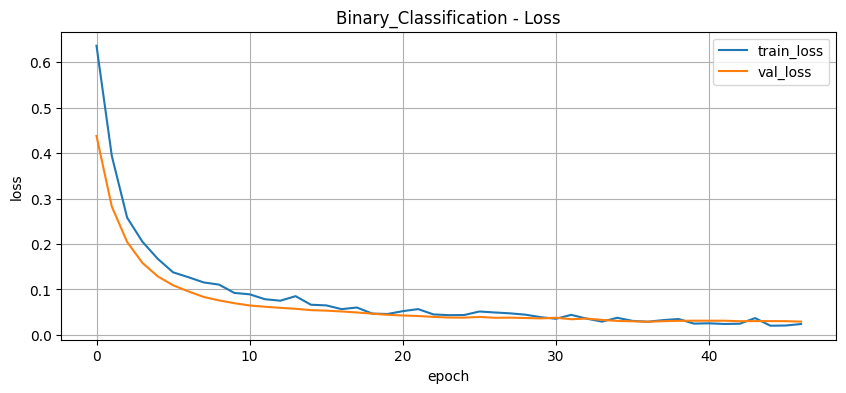

In [26]:
# 모델 성능 확인
# Loss
plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Binary_Classification - Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

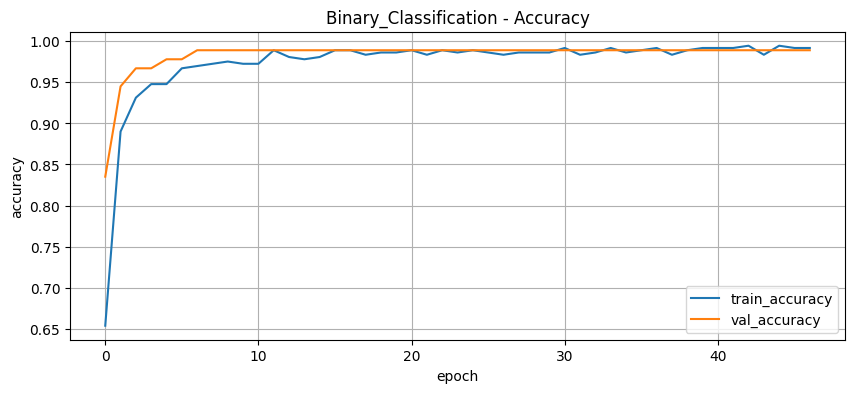

In [27]:
# accuracy
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Binary_Classification - Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
plt.grid(True)
plt.show()

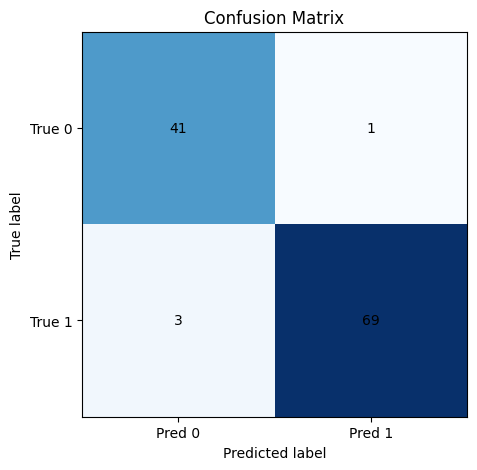

In [28]:
# confusion matrix 시각화
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")   # confusion matrix를 이미지 형태로 출력 (파란색 계열)
plt.title("Confusion Matrix")

# x축과 y축 눈금 설정
plt.xticks([0,1], ["Pred 0", "Pred 1"])  # 예측값 (열 기준)
plt.yticks([0,1], ["True 0", "True 1"])  # 실제값 (행 기준)

# CM 내부에 숫자 표시
# cm.shape → (행 개수, 열 개수)
for i in range(cm.shape[0]):       # 행 반복
    for j in range(cm.shape[1]):   # 열 반복
        plt.text(j, i, cm[i, j],   # (x=j, y=i) 위치에 숫자 출력
                 ha="center",      # 가로 중앙 정렬
                 va="center")      # 세로 중앙 정렬

plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.show()

In [29]:
# scaler 객체를 "Binary_Classification.pkl" 파일로 저장
# (학습된 스케일링 기준을 나중에 재사용하기 위함)
joblib.dump(scaler, "./results/9-01) Binary_Classification.pkl")

['./results/9-01) Binary_Classification.pkl']

In [31]:
# 신규 데이터 예측 (추론)
new_data = X_test[:5]

# 저장해둔 scaler 불러오기 (학습 때 사용한 기준 그대로 사용)
loaded_scaler = joblib.load("./results/9-01) Binary_Classification.pkl")

# 동일한 스케일링 적용
new_data_scaled = loaded_scaler.transform(new_data)

# 모델을 이용해 예측 확률 계산 (0~1 사이 값)
new_prob = loaded_model.predict(new_data_scaled)

# 확률을 기준으로 클래스 변환 (0.5 이상 → 1, 미만 → 0)
# flatten(): 2차원 배열을 1차원으로 변환
new_pred = (new_prob >= 0.5).astype(int).flatten()

# 각 샘플별 예측 결과 출력
for i in range(len(new_data)):
    # 예측 확률은 소수점 4자리까지 출력
    print(f"{i+1}번 샘플 - 예측확률: {new_prob[i][0]:.4f}, 예측클래스: {new_pred[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step
1번 샘플 - 예측확률: 0.0000, 예측클래스: 0
2번 샘플 - 예측확률: 1.0000, 예측클래스: 1
3번 샘플 - 예측확률: 0.0005, 예측클래스: 0
4번 샘플 - 예측확률: 0.5056, 예측클래스: 1
5번 샘플 - 예측확률: 0.0000, 예측클래스: 0
